# Project 11 — Implementing Output Activations

## Project Description

**Objective**: Build and compare output activation functions from scratch.

**Using NumPy and Matplotlib**:

1. Implement:
   - Sigmoid,
   - Softmax.
1. Plot the sigmoid function over the interval [−8,8].
1. Generate several sets of logits and compute their Softmax probabilities.
1. Demonstrate that:
   - probabilities are non-negative,
   - probabilities sum to one.
1. Implement the numerically stable Softmax by subtracting the maximum logit before exponentiation.
1. Compare the outputs of the naive and numerically stable implementations for:
   - small logits,
   - very large logits.

Write a brief report explaining why numerical stability is crucial in practical deep learning implementations.

## My Solution

In [1]:
import matplotlib.pyplot as plt
import numpy as np


# 1. Implementation of Output Activations

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def softmax_naive(z):
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=-1, keepdims=True)


def softmax_stable(z):
    shift_z = z - np.max(z, axis=-1, keepdims=True)
    exp_z = np.exp(shift_z)
    return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

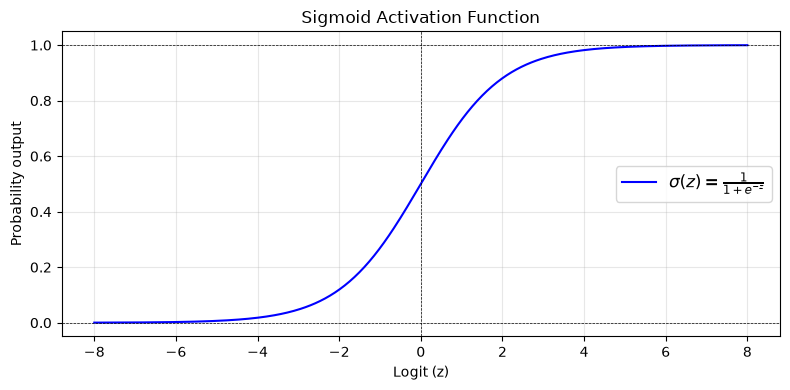

In [2]:
# 2. Plotting Sigmoid over [-8, 8]

z_vals = np.linspace(-8, 8, 400)
sig_vals = sigmoid(z_vals)

plt.figure(figsize=(8, 4))
plt.plot(z_vals, sig_vals, label=r"$\sigma(z) = \frac{1}{1 + e^{-z}}$", color="b")
plt.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.axhline(1, color="black", linewidth=0.5, linestyle="--")
plt.axvline(0, color="black", linewidth=0.5, linestyle="--")
plt.title("Sigmoid Activation Function")
plt.xlabel("Logit (z)")
plt.ylabel("Probability output")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [3]:
# 3 & 4. Logit Generation & Axiom Verification

np.random.seed(42)
sample_logits = np.array(
    [[2.0, 1.0, 0.1], [-1.5, 0.0, 3.2], [10.0, 10.0, 10.0]]
)

probs = softmax_stable(sample_logits)

print("--- Sample Logits and Softmax Probabilities ---")
for i, (logit, prob) in enumerate(zip(sample_logits, probs)):
    is_non_negative = np.all(prob >= 0)
    sum_is_one = np.isclose(np.sum(prob), 1.0)
    print(f"Set {i+1} Logits: {logit}")
    print(f"Set {i+1} Softmax Probs: {np.round(prob, 4)}")
    print(f"  - Non-negative? {is_non_negative}")
    print(f"  - Sums to 1.0?   {sum_is_one} (Sum = {np.sum(prob):.6f})\n")

--- Sample Logits and Softmax Probabilities ---
Set 1 Logits: [2.  1.  0.1]
Set 1 Softmax Probs: [0.659  0.2424 0.0986]
  - Non-negative? True
  - Sums to 1.0?   True (Sum = 1.000000)

Set 2 Logits: [-1.5  0.   3.2]
Set 2 Softmax Probs: [0.0087 0.0388 0.9525]
  - Non-negative? True
  - Sums to 1.0?   True (Sum = 1.000000)

Set 3 Logits: [10. 10. 10.]
Set 3 Softmax Probs: [0.3333 0.3333 0.3333]
  - Non-negative? True
  - Sums to 1.0?   True (Sum = 1.000000)



In [4]:
# 5 & 6. Naive vs. Numerically Stable Softmax

small_logits = np.array([1.0, 2.0, 3.0])
large_logits = np.array([1000.0, 1001.0, 1002.0])

print("--- Softmax Comparison: Small vs. Large Logits ---")
print("Small Logits:", small_logits)
print("  Naive: ", softmax_naive(small_logits))
print("  Stable:", softmax_stable(small_logits))

print("\nLarge Logits:", large_logits)
print("  Naive: ", softmax_naive(large_logits))  # Causes overflow (NaN/Inf)
print("  Stable:", softmax_stable(large_logits))

--- Softmax Comparison: Small vs. Large Logits ---
Small Logits: [1. 2. 3.]
  Naive:  [0.09003057 0.24472847 0.66524096]
  Stable: [0.09003057 0.24472847 0.66524096]

Large Logits: [1000. 1001. 1002.]
  Naive:  [nan nan nan]
  Stable: [0.09003057 0.24472847 0.66524096]


C:\Users\oogway\AppData\Local\Temp\ipykernel_2396\2834704039.py:12: RuntimeWarning: overflow encountered in exp
  exp_z = np.exp(z)
C:\Users\oogway\AppData\Local\Temp\ipykernel_2396\2834704039.py:13: RuntimeWarning: invalid value encountered in divide
  return exp_z / np.sum(exp_z, axis=-1, keepdims=True)


## Numerical Stability Report

Numerical stability is essential in deep learning due to how computers store real numbers using 64-bit or 32-bit floating-point precision (IEEE 754 standard).

1. **The Mechanics of Softmax Overflow**: The standard Softmax formula is defined as: $$P(y = i \mid z) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$ In 64-bit floating-point arithmetic (float64), $e^{z}$ overflows to inf when $z \gtrsim 709.78$. In 32-bit floating-point arithmetic (float32), which is standard for deep learning frameworks, $e^{z}$ overflows when $z \gtrsim 88.72$. When logits exceed these thresholds:$e^{z_i}$ yields inf. $\frac{\text{inf}}{\text{inf}}$ evaluates to NaN (Not a Number).Gradients become NaN, completely corrupting model weights during backpropagation.
2. **Mathematical Proof of Shift Invariance**: To prevent overflow without altering output probabilities, Softmax utilizes shift invariance by subtracting a constant $C = \max(z)$ from all logits:$$\frac{e^{z_i - C}}{\sum_{j} e^{z_j - C}} = \frac{e^{z_i} \cdot e^{-C}}{\sum_{j} (e^{z_j} \cdot e^{-C})} = \frac{e^{-C} \cdot e^{z_i}}{e^{-C} \cdot \sum_{j} e^{z_j}} = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$Subtracting $C = \max(z)$ guarantees that the largest exponent input is $(z_{\max} - z_{\max}) = 0$. Since $e^0 = 1$, the largest value passed to exp() is capped at 1.0, making numerical overflow physically impossible regardless of how large the initial logits are.

## What ChatGPT Expected Me to Learn from this Project

Project 11 was your first opportunity to implement a component exactly as deep learning libraries do.

The key ideas were:

- Softmax is just a mathematical transformation.
- Numerical stability matters in real implementations.
- Frameworks hide complexity, but understanding the underlying computations helps you debug and reason about models.